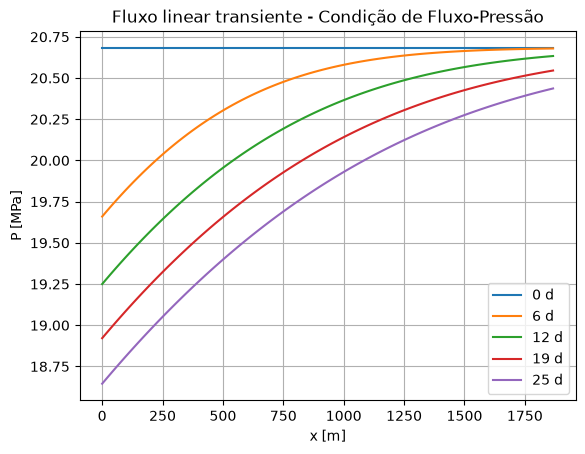

In [3]:
#transient 1D linear solution with conditions flow-pressure

import numpy as np
import matplotlib.pyplot as plt

from analytical.transiente_L1d_FP import linear_trans_1d_FP

# parameters
p0 = 20.684e6                # pressão em x = L e pressão inicial [Pa]
A_R = 3484800              # área do reservatório [m²]
L = np.sqrt(A_R)                     # comprimento (considerando um reservatório quadrado) [m]
qw = 4.968e-3             # vazão volumétrica no reservatório [m³/s] 
k = 339*9.869233e-16      # permeabilidade [m²]
phi = 0.22                # porosidade [-]
ct = 3.046e-9                # compressibilidade total [1/Pa]
mu = 1.0e-3 # viscosidade [Pa.s]  =  1 cP
t_h = 25 # tempo [d]
t_final = t_h*86400       # tempo [s]
eta  =  k / (phi * ct * mu)
h = 4.572                     # espessura [m]                 
A = h*L

x, t, X, T, P = linear_trans_1d_FP(p0, qw, L, k, A, mu, eta, t_final)
# P em função de x
tempos_escolhidos = np.linspace(0, t_h, 5)  # horas

for tempo in tempos_escolhidos:

    t_escolhido = tempo * 86400

    indice_t = np.argmin(np.abs(t - t_escolhido))

    plt.plot(x, P[indice_t, :] / 1e6, label=f'{t[indice_t]/86400:.0f} d')

plt.xlabel('x [m]')
plt.ylabel('P [MPa]')
plt.title('Fluxo linear transiente - Condição de Fluxo-Pressão')

plt.legend()
plt.grid()

plt.savefig(
    'fluxo_linear_transiente_FP.pdf',
    dpi=300,
    bbox_inches='tight'
)

plt.show()